# Camber Sands — multi-model 24h AROME correction (seq2seq GRU)

Same setup as the single-model 24h notebook, but the GRU is now fed **three NWP models** as input channels: **Météo-France AROME HD (1.5km)**, **UK Met Office UKV (2km)**, and **DWD ICON-D2 (2.2km)** — three different modelling cores, so genuinely independent information.

- We still **correct AROME** (target = `observed - AROME`, corrected = AROME + residual) — the other models are *inputs* that help predict AROME's error.
- This notebook trains the **AROME-only** and the **multi-model** GRU on identical windows for a fair head-to-head.
- Key earlier finding: the naive 3-model *mean* is worse than AROME alone — the gain comes from the GRU learning a **conditional** blend, not averaging.

> ECMWF IFS was excluded: its Open-Meteo archive only starts 2024 (vs 2022-11 for the others), which would gut the training window.

In [1]:
%matplotlib inline
import json
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
DEVICE='cpu'
H, F = 10, 24
HIDDEN, WEIGHT_DECAY = 32, 1e-4
DATA=Path('..')/'data'
MERGED=DATA/'station_53_camber-sands_red-house_merged.parquet.enc'    # observed+AROME+UKV+ICON-D2 (encrypted)
print('torch', torch.__version__)

torch 2.12.1


## 1. Decrypt & load merged data, quality-control

The merged dataset (observed + AROME + UKV + ICON-D2) is stored **encrypted** at `data/station_53_camber-sands_red-house_merged.parquet.enc`. It is decrypted in-memory using the passphrase from the **`ARCHIVE_KEY`** environment variable, which must be set before launching Jupyter / running the notebook.

In [2]:
import os, sys
sys.path.append(str(Path('..')/'scripts'))
from archive_crypto import read_encrypted_parquet
KEY=os.environ.get('ARCHIVE_KEY')
if not KEY:
    raise RuntimeError('ARCHIVE_KEY env var not set - needed to decrypt the merged archive')
df=read_encrypted_parquet(MERGED, KEY).sort_values('datetime').reset_index(drop=True)
need=['wind_avg_kt','wind_max_kt','wind_dir_deg','arome_wind_10m_kt','arome_gust_10m_kt','arome_wind_dir_deg','arome_temp_2m_c',
      'ukv_wind_10m_kt','ukv_gust_10m_kt','ukv_wind_dir_deg','icond2_wind_10m_kt','icond2_gust_10m_kt','icond2_wind_dir_deg']
df=df.dropna(subset=need).reset_index(drop=True)
dead=(df['wind_avg_kt']==0)&(df['wind_max_kt']==0)
df=df[~dead].reset_index(drop=True)
print(f'merged clean rows: {len(df):,}  ({df.datetime.min()} -> {df.datetime.max()})  | dropped {dead.sum()} dead-sensor')

merged clean rows: 23,980  (2023-04-21 19:00:00+00:00 -> 2026-06-17 01:00:00+00:00)  | dropped 1831 dead-sensor


## 2. Features & windowing
Base AROME channels (as before) **plus** UKV and ICON-D2 wind / gust / direction at every history *and* future hour (they are forecasts, so known across the whole 34h window). We build all channels once, then slice columns to form the AROME-only vs multi-model inputs.

In [3]:
hr=df['datetime'].dt.hour.values; df['hour_sin'],df['hour_cos']=np.sin(2*np.pi*hr/24),np.cos(2*np.pi*hr/24)
for c,a,b in [('wind_dir_deg','obs_dir_sin','obs_dir_cos'),('arome_wind_dir_deg','fc_dir_sin','fc_dir_cos'),
              ('ukv_wind_dir_deg','ukv_dir_sin','ukv_dir_cos'),('icond2_wind_dir_deg','icond2_dir_sin','icond2_dir_cos')]:
    df[a],df[b]=np.sin(np.deg2rad(df[c].astype(float))),np.cos(np.deg2rad(df[c].astype(float)))

SEQ0=['wind_avg_kt','wind_max_kt','obs_dir_sin','obs_dir_cos','arome_wind_10m_kt','arome_gust_10m_kt','fc_dir_sin','fc_dir_cos','arome_temp_2m_c','hour_sin','hour_cos']
FUT0=['arome_wind_10m_kt','arome_gust_10m_kt','fc_dir_sin','fc_dir_cos','arome_temp_2m_c','hour_sin','hour_cos']
EX  =['ukv_wind_10m_kt','ukv_gust_10m_kt','ukv_dir_sin','ukv_dir_cos','icond2_wind_10m_kt','icond2_gust_10m_kt','icond2_dir_sin','icond2_dir_cos']
SEQ_ALL, FUT_FEAT = SEQ0+EX, FUT0+EX

gap=np.r_[True, df['datetime'].diff().dt.total_seconds().values[1:]!=3600]; rid=np.cumsum(gap)
seqM=df[SEQ_ALL].values.astype(np.float32); futM=df[FUT_FEAT].values.astype(np.float32)
ow,og=df['wind_avg_kt'].values.astype(np.float32),df['wind_max_kt'].values.astype(np.float32)
fw,fg=df['arome_wind_10m_kt'].values.astype(np.float32),df['arome_gust_10m_kt'].values.astype(np.float32)
tv=df['datetime'].values; lead=((np.arange(F)+1)/F).astype(np.float32)
Xh,Xf,Y,Aw,Ag,OW,OG,Pw,Pg,T=[],[],[],[],[],[],[],[],[],[]
for _,idx in pd.Series(np.arange(len(df))).groupby(rid):
    idx=idx.values
    for i in range(len(idx)-(H+F)+1):
        hs=idx[i:i+H]; fu=idx[i+H:i+H+F]
        Xh.append(seqM[hs]); Xf.append(np.c_[futM[fu],lead]); Y.append(np.stack([ow[fu]-fw[fu],og[fu]-fg[fu]],1))
        Aw.append(fw[fu]); Ag.append(fg[fu]); OW.append(ow[fu]); OG.append(og[fu])
        Pw.append(np.full(F,ow[hs[-1]],np.float32)); Pg.append(np.full(F,og[hs[-1]],np.float32)); T.append(tv[fu[0]])
Xh=np.array(Xh);Xf=np.array(Xf);Y=np.array(Y,np.float32)
Aw=np.array(Aw);Ag=np.array(Ag);OW=np.array(OW);OG=np.array(OG);Pw=np.array(Pw);Pg=np.array(Pg);T=np.array(T)
print(f'{len(Xh):,} windows | hist {Xh.shape} | fut {Xf.shape}')

# chronological split + standardize on train stats
order=np.argsort(T); cut=int(len(order)*0.8); tr,va=order[:cut],order[cut:]
sm=Xh[tr].reshape(-1,Xh.shape[2]).mean(0); ss=Xh[tr].reshape(-1,Xh.shape[2]).std(0)+1e-6
fm=Xf[tr].reshape(-1,Xf.shape[2]).mean(0); fs=Xf[tr].reshape(-1,Xf.shape[2]).std(0)+1e-6
ym=Y[tr].reshape(-1,2).mean(0); ysd=Y[tr].reshape(-1,2).std(0)+1e-6
z=lambda a,m,s:((a-m)/s).astype(np.float32)
Xh_t=torch.tensor(z(Xh,sm,ss)); Xf_t=torch.tensor(z(Xf,fm,fs)); Y_t=torch.tensor(z(Y,ym,ysd))
tri,vai=torch.tensor(tr),torch.tensor(va)

# column indices: AROME-only vs multi-model
n0,nex,nf0=len(SEQ0),len(EX),len(FUT0)
arome_seq=list(range(n0));                 mm_seq=list(range(n0+nex))
arome_fut=list(range(nf0))+[nf0+nex];      mm_fut=list(range(nf0+nex+1))
print('AROME-only channels: seq',len(arome_seq),'fut',len(arome_fut),'| multi-model: seq',len(mm_seq),'fut',len(mm_fut))

22,309 windows | hist (22309, 10, 19) | fut (22309, 24, 16)
AROME-only channels: seq 11 fut 8 | multi-model: seq 19 fut 16


## 3. Model + training function

In [4]:
class Seq2Seq(nn.Module):
    def __init__(self, n_seq, n_fut, hidden=HIDDEN):
        super().__init__()
        self.enc=nn.GRU(n_seq,hidden,batch_first=True); self.dec=nn.GRU(n_fut,hidden,batch_first=True)
        self.head=nn.Sequential(nn.Linear(hidden,64),nn.ReLU(),nn.Dropout(0.1),nn.Linear(64,2))
    def forward(self,hist,fut):
        _,h=self.enc(hist); out,_=self.dec(fut,h); return self.head(out)

def train_eval(seq_idx, fut_idx, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    si,fi=torch.tensor(seq_idx),torch.tensor(fut_idx)
    Hh,Ff=Xh_t[:,:,si],Xf_t[:,:,fi]
    m=Seq2Seq(len(seq_idx),len(fut_idx)).to(DEVICE)
    opt=torch.optim.Adam(m.parameters(),1e-3,weight_decay=WEIGHT_DECAY); lf=nn.MSELoss()
    hist={'train':[],'val':[]}; best,bad,bstate,bep=1e9,0,None,-1
    for ep in range(60):
        m.train(); perm=tri[torch.randperm(len(tri))]; run=0.0
        for jx in range(0,len(perm),128):
            b=perm[jx:jx+128]; opt.zero_grad(); loss=lf(m(Hh[b],Ff[b]),Y_t[b]); loss.backward(); opt.step(); run+=loss.item()*len(b)
        m.eval()
        with torch.no_grad(): vl=lf(m(Hh[vai],Ff[vai]),Y_t[vai]).item()
        hist['train'].append(run/len(tri)); hist['val'].append(vl)
        if vl<best-1e-4: best,bad,bep,bstate=vl,0,ep,{k:v.clone() for k,v in m.state_dict().items()}
        else: bad+=1
        if bad>=12: break
    m.load_state_dict(bstate); m.eval()
    with torch.no_grad(): pred=m(Hh[vai],Ff[vai]).numpy()*ysd+ym
    cw,cg=Aw[va]+pred[:,:,0], Ag[va]+pred[:,:,1]
    return {'cw':cw,'cg':cg,'hist':hist,'best_ep':bep,'state':bstate}

## 4. Train AROME-only and multi-model (identical windows)

In [5]:
res_arome=train_eval(arome_seq, arome_fut)
res_mm   =train_eval(mm_seq,    mm_fut)
print('AROME-only  best epoch', res_arome['best_ep'])
print('multi-model best epoch', res_mm['best_ep'])

AROME-only  best epoch 15
multi-model best epoch 8


## 5. Per-lead evaluation (val, wind RMSE in kt)

In [6]:
rmse_l=lambda a,b: np.sqrt(np.mean((a-b)**2,0))   # per-lead
perlead=pd.DataFrame({
    'AROME_raw':   rmse_l(Aw[va],OW[va]),
    'persistence': rmse_l(Pw[va],OW[va]),
    'GRU_AROME':   rmse_l(res_arome['cw'],OW[va]),
    'GRU_multimodel': rmse_l(res_mm['cw'],OW[va])}, index=np.arange(1,F+1))
perlead.index.name='lead_h'
mean=perlead.mean().round(3)
imp_vs_arome_gru=100*(mean.GRU_AROME-mean.GRU_multimodel)/mean.GRU_AROME
imp_vs_raw=100*(mean.AROME_raw-mean.GRU_multimodel)/mean.AROME_raw
print('mean over 24h:'); print(mean.to_string())
print(f'\nmulti-model GRU: {imp_vs_arome_gru:+.1f}% vs AROME-only GRU | {imp_vs_raw:+.1f}% vs raw AROME')
perlead.loc[[1,3,6,12,18,24]].round(2)

mean over 24h:
AROME_raw         3.495
persistence       7.179
GRU_AROME         2.256
GRU_multimodel    1.972

multi-model GRU: +12.6% vs AROME-only GRU | +43.6% vs raw AROME


,AROME_raw,persistence,GRU_AROME,GRU_multimodel
lead_h,,,,
1,3.49,2.17,1.76,1.64
3,3.49,4.16,2.20,1.93
6,3.49,6.02,2.28,1.99
12,3.50,7.83,2.29,2.00
18,3.50,8.61,2.30,2.00
24,3.50,8.99,2.30,2.00


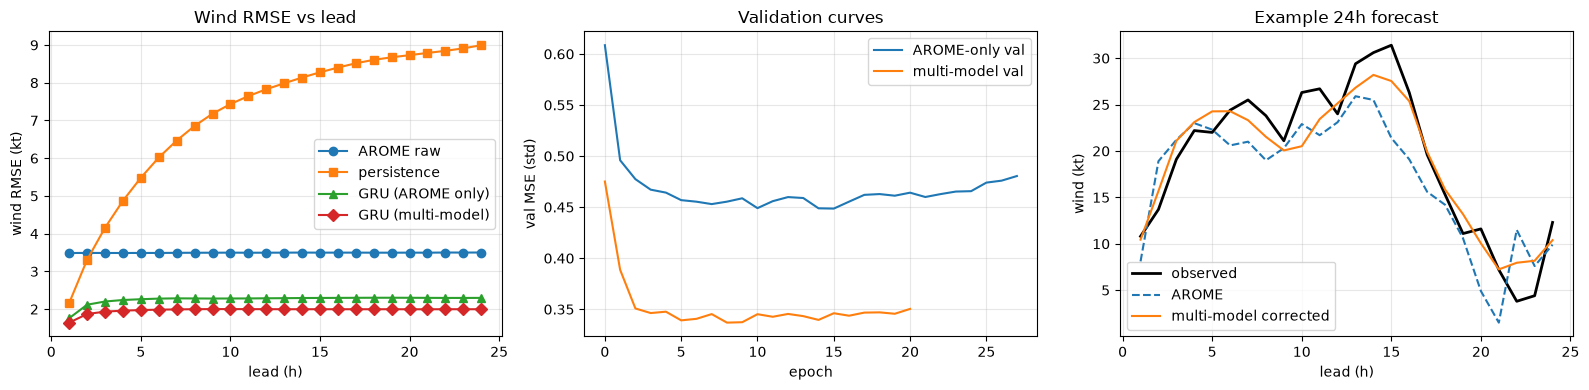

In [7]:
fig,ax=plt.subplots(1,3,figsize=(16,4)); Lx=np.arange(1,F+1)
ax[0].plot(Lx,perlead.AROME_raw,'o-',label='AROME raw'); ax[0].plot(Lx,perlead.persistence,'s-',label='persistence')
ax[0].plot(Lx,perlead.GRU_AROME,'^-',label='GRU (AROME only)'); ax[0].plot(Lx,perlead.GRU_multimodel,'D-',label='GRU (multi-model)')
ax[0].set_xlabel('lead (h)'); ax[0].set_ylabel('wind RMSE (kt)'); ax[0].set_title('Wind RMSE vs lead'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(res_arome['hist']['val'],label='AROME-only val'); ax[1].plot(res_mm['hist']['val'],label='multi-model val')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val MSE (std)'); ax[1].set_title('Validation curves'); ax[1].legend(); ax[1].grid(alpha=.3)
e=120
ax[2].plot(Lx,OW[va][e],'k-',lw=2,label='observed'); ax[2].plot(Lx,Aw[va][e],'--',label='AROME')
ax[2].plot(Lx,res_mm['cw'][e],'-',label='multi-model corrected')
ax[2].set_xlabel('lead (h)'); ax[2].set_ylabel('wind (kt)'); ax[2].set_title('Example 24h forecast'); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Conclusion & save
Feeding UKV + ICON-D2 as extra channels cuts wind RMSE another **~13%** below the AROME-only correction (**~44% below raw AROME**), holding across the whole 24h horizon. The gain is a *learned conditional blend* — recall the naive 3-model mean was worse than AROME alone.

**Next levers:** multi-station pooling (Camber+Greatstone+Southend with a station embedding); add ECMWF IFS on its shorter 2024+ window; a quantile head for gusts.

In [8]:
MODELS=Path('..')/'models'; MODELS.mkdir(exist_ok=True)
torch.save({'state_dict':res_mm['state'],'seq_cols':SEQ_ALL,'fut_cols':FUT_FEAT+['lead_frac'],'H':H,'F':F,
            'norm':{'sm':sm,'ss':ss,'fm':fm,'fs':fs,'ym':ym,'ysd':ysd}}, MODELS/'camber_multimodel_gru_24h.pt')
perlead.round(4).to_json('camber_multimodel_perlead_metrics.json', indent=2)
print('saved -> models/camber_multimodel_gru_24h.pt and notebooks/camber_multimodel_perlead_metrics.json')

saved -> models/camber_multimodel_gru_24h.pt and notebooks/camber_multimodel_perlead_metrics.json
